### Import Python packages

In [36]:
import ast
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from math import radians, sin, cos, sqrt, atan2
from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# Part 1: Compute the correlation between temperatures of sheep

### Read file that contains information about animals

In [37]:
df_animals = pd.read_csv('data/animals.csv')
print('There are', df_animals.shape[0], 'in total')

There are 16 in total


### Show all rows of the dataframe

In [38]:
df_animals.head(16)

,id,id_api,name,birth,type,sex,breed,breed_short,farm_id_api,farm_id
0,7,DT557,Μαϊστράλω (Χιώτικο) ...,2023-07-17 03:00:00,SHEEP ...,FEMALE ...,East Friesian ...,EAF ...,2,3
1,8,DT558,Λάγια (Μπούτσικο) ...,2023-07-17 03:00:00,SHEEP ...,FEMALE ...,Zackel ...,ZAC ...,2,3
2,6,DS532,Μουσχούρη ...,2020-07-28 03:00:00,SHEEP ...,FEMALE ...,Arkhar-Merino ...,ARK ...,1,2
3,9,DT559,Κρούτα ...,2023-07-17 03:00:00,SHEEP ...,FEMALE ...,Karagouniko ...,KAR ...,2,3
4,13,DW279,Μαυρομάτα ...,2021-07-28 03:00:00,SHEEP ...,FEMALE ...,Pramenka ...,PRA ...,4,4
5,2,DQ174,Μπέλα Σκουλαρικάτη ...,2022-07-28 03:00:00,SHEEP ...,FEMALE ...,Karagouniko ...,KAR ...,4,4
6,12,DW278,Μπέλης ...,2022-09-01 03:00:00,SHEEP ...,MALE ...,Lacaune ...,LAC ...,6,5
7,3,DR978,Αμελί ...,2021-09-01 03:00:00,SHEEP ...,FEMALE ...,Lacaune ...,LAC ...,6,5
8,15,DW284,Κοκκίνα ...,2022-07-28 03:00:00,SHEEP ...,FEMALE ...,Arkhar-Merino ...,ARK ...,1,2
9,1,CS342,Μπέλα ...,2023-05-21 03:00:00,SHEEP ...,FEMALE ...,Karagouniko ...,KAR ...,1,2


### Delete whitespace in strings and sort based on farm id

In [39]:
# Delete whitespace
df_animals = df_animals.map(lambda x: x.strip() if isinstance(x, str) else x)

# Sort by farm
df_animals = df_animals.sort_values(by='farm_id_api')
df_animals.head(16)

,id,id_api,name,birth,type,sex,breed,breed_short,farm_id_api,farm_id
2,6,DS532,Μουσχούρη,2020-07-28 03:00:00,SHEEP,FEMALE,Arkhar-Merino,ARK,1,2
8,15,DW284,Κοκκίνα,2022-07-28 03:00:00,SHEEP,FEMALE,Arkhar-Merino,ARK,1,2
9,1,CS342,Μπέλα,2023-05-21 03:00:00,SHEEP,FEMALE,Karagouniko,KAR,1,2
0,7,DT557,Μαϊστράλω (Χιώτικο),2023-07-17 03:00:00,SHEEP,FEMALE,East Friesian,EAF,2,3
1,8,DT558,Λάγια (Μπούτσικο),2023-07-17 03:00:00,SHEEP,FEMALE,Zackel,ZAC,2,3
3,9,DT559,Κρούτα,2023-07-17 03:00:00,SHEEP,FEMALE,Karagouniko,KAR,2,3
4,13,DW279,Μαυρομάτα,2021-07-28 03:00:00,SHEEP,FEMALE,Pramenka,PRA,4,4
5,2,DQ174,Μπέλα Σκουλαρικάτη,2022-07-28 03:00:00,SHEEP,FEMALE,Karagouniko,KAR,4,4
10,4,DS346,Κόκκινη,2021-07-28 03:00:00,SHEEP,FEMALE,Pramenka,PRA,4,4
11,5,DS531,Παρδάλω,2019-07-28 03:00:00,SHEEP,FEMALE,Pramenka,PRA,4,4


### Read file that contains data from the sheep collars

In [40]:
df_device_data = pd.read_csv('data/device_data.csv')
df_device_data.head()

,id,id_api,created,acc_x,acc_y,acc_z,std_x,std_y,std_z,max_x,max_y,max_z,temperature,coordinates
0,55562,CS342,2025-09-15 01:29:17,-4096,-2048,-14336,0,224,224,359,359,1140,28.5,"(22.413794156,37.427252613)"
1,55563,CS342,2025-09-15 02:29:11,8192,-2048,-14336,533,533,884,2241,1140,3620,29.2,"(22.413611048,37.427359426)"
2,55700,DQ174,2025-09-15 00:21:27,-10240,-12288,2048,224,0,224,359,359,359,27.3,"(22.250797284,37.368825818)"
3,55701,DQ174,2025-09-15 00:35:55,-10240,-12288,0,0,0,224,359,359,1140,27.3,"(22.250827802,37.368810559)"
4,55702,DQ174,2025-09-15 00:51:00,-12288,-10240,-2048,224,0,224,359,359,1140,26.1,"(22.250797284,37.368856336)"


In [41]:
df_device_data.shape

(23309, 14)

### Convert values of 'created' column into datetime objects and sort chronologically 

In [42]:
df_device_data['created'] = pd.to_datetime(df_device_data['created'])
df_device_data = df_device_data.sort_values(by='created')
df_device_data.head(-10)

,id,id_api,created,acc_x,acc_y,acc_z,std_x,std_y,std_z,max_x,max_y,max_z,temperature,coordinates
30,56257,DT557,2025-09-15 00:03:59,-10240,-10240,-6144,0,0,224,359,359,359,34.7,"(23.706172274,37.984649424)"
62,56764,DT559,2025-09-15 00:05:21,-12288,-6144,-8192,0,0,224,0,0,359,34.1,"(23.706569009,37.984573129)"
24,56012,DS532,2025-09-15 00:06:29,0,-6144,-14336,1267,533,224,2241,1140,1140,31.0,"(22.413839933,37.427115282)"
46,56506,DT558,2025-09-15 00:07:15,2048,-12288,-12288,224,224,224,1140,1140,1140,33.5,"(23.706569009,37.98440528)"
78,56820,DU043,2025-09-15 00:10:26,-10240,-14336,-2048,224,224,224,359,359,1140,24.8,"(22.25070573,37.369054704)"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23185,192992,DU043,2025-10-15 23:29:08,-6144,-16384,-2048,224,0,533,359,359,11493,25.5,"(22.250324254,37.368963149)"
23057,192690,DT558,2025-10-15 23:33:16,-8192,-8192,-10240,0,0,224,359,359,359,31.0,"(23.706370642,37.98455787)"
23297,193237,DW284,2025-10-15 23:33:51,0,-6144,-14336,0,0,224,359,0,359,17.4,"(22.41388571,37.427100023)"
22947,192439,DT557,2025-10-15 23:34:29,-10240,-8192,-8192,224,0,224,359,359,1140,31.6,"(23.706279088,37.984771496)"


### Align temperature records for pairs of animals and compute the correlation between their temperatures

The Pearson correlation coefficient measures the linear correlation between two sets of data. It is computed as follows:

$$
r_{xy} = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n} (x_i - \bar{x})^2} \sqrt{\sum_{i=1}^{n} (y_i - \bar{y})^2}}
$$

where $x_i$, $y_i$ denote the $i$-th value of each set of data, $n$ is the number of samples in each set, and $\bar{x}, \bar{y}$ denote the mean valyes of the two datasets.

If $x=[1,2,3,4,5,4,3,2,1]^\top$ and $y=[2,4,6,8,10,8,6,4,2]^\top$, then $r_{xy} = 1$.

If $x=[1,2,3,4,5]^\top$ and $y=[2,0,2,0,2]^\top$, then $r_{xy} = 0$

In [43]:
num_animals = df_animals.shape[0]
device_ids = df_animals['id_api'].tolist()

# Inititalize square matrix to store correlations
A = np.zeros((num_animals, num_animals))

for i in range(num_animals):
    df1 = df_device_data[df_device_data['id_api'] == device_ids[i]].copy()
    df1 = df1[['created', 'temperature']]
    for j in range(i, num_animals):
        df2 = df_device_data[df_device_data['id_api'] == device_ids[j]].copy()
        df2 = df2[['created', 'temperature']]

        # Merge df1 and df2 based on time
        # Match each row from df1 with the nearest row in df2 based on 'created'
        df_merged = pd.merge_asof(
            df1, df2,
            on='created',
            direction='nearest',  
            tolerance=pd.Timedelta('30min'),
            suffixes=('_df1', '_df2')
        )

        # Drop rows where no match was found
        df_merged = df_merged.dropna()

        # Extract aligned temperatures from df1 and df2
        temp1 = df_merged['temperature_df1'].tolist()
        temp2 = df_merged['temperature_df2'].tolist()

        # Compute pearson correlation and store in matrix A
        A[i,j] = pearsonr(temp1, temp2)[0]
        A[j,i] = A[i,j]

### Visualize correlations

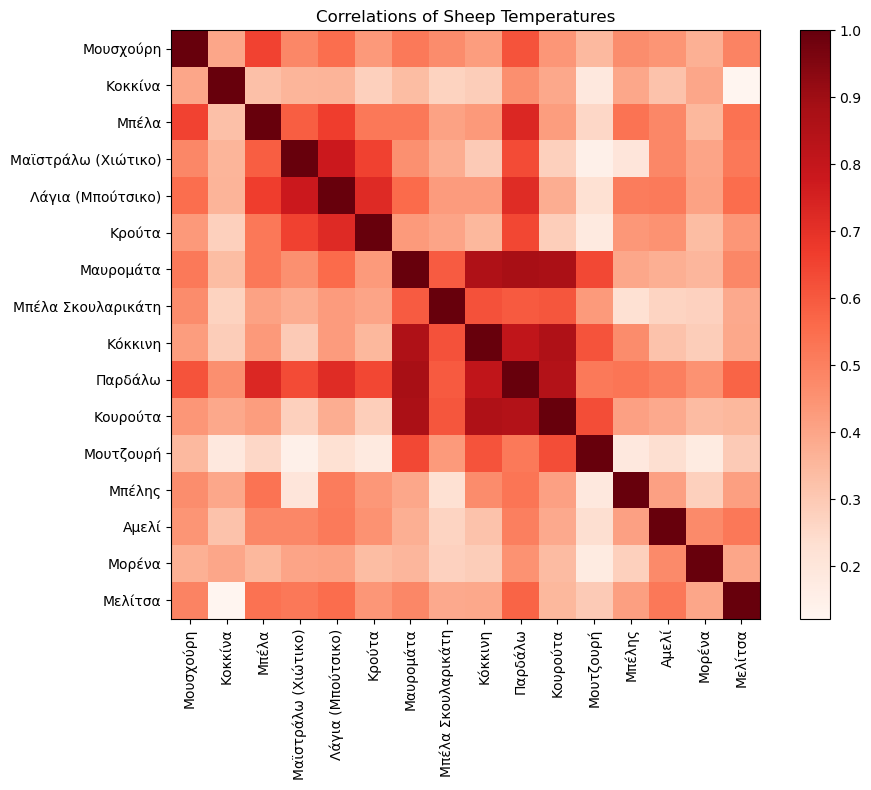

In [44]:
# Get names of animals
animal_names = df_animals['name'].tolist()

# Initialize figure
plt.figure(figsize=(10, 8))

# Show matrix as an image
im = plt.imshow(A, cmap='Reds')

# Add colorbar
plt.colorbar(im)

# Set ticks and labels
plt.xticks(ticks=np.arange(len(animal_names)), labels=animal_names, rotation=90)
plt.yticks(ticks=np.arange(len(animal_names)), labels=animal_names, rotation=0)

# Set title
plt.title("Correlations of Sheep Temperatures")
plt.tight_layout()

# Part 2: Compute the correlation between animal temperatures and ambient temperatures from nearby weather stations

### Read file that contains meteorological data

In [45]:
df_meteo = pd.read_csv('data/meteo_data.csv')
df_meteo.head()

,farm_id_api,farm_name,farm_longitude,farm_latitude,station_source,station_timedata,crawled,station_city,station_nomos,station_longitude,...,temperature,humidity,wind,direction,yetos,barometer,dew_point,heat_index,wind_chill,solar_radiation
0,1,KFarm,22.413729,37.427095,SoDa,2025-09-14 22:48:39.000000,2025-09-15 00:00:31.378430+03:00,Λίμνη Τάκα,Αρκαδίας,22.378898,...,25.639999,68.148001,5.6,236.353745,0.0,938.701294,21.982269,NaN,NaN,145.844543
1,1,KFarm,22.413729,37.427095,SoDa,2025-09-15 16:29:46.000000,2025-09-15 00:20:24.156691+03:00,Λίμνη Τάκα,Αρκαδίας,22.378898,...,25.040001,74.709002,7.1,233.629440,0.0,938.500000,21.950001,NaN,NaN,40.086655
2,1,KFarm,22.413729,37.427095,SoDa,2025-09-15 16:39:46.000000,2025-09-15 00:40:22.674919+03:00,Λίμνη Τάκα,Αρκαδίας,22.378898,...,24.530001,78.849001,5.5,255.176941,0.0,938.600000,22.219999,NaN,NaN,19.407743
3,1,KFarm,22.413729,37.427095,SoDa,2025-09-15 16:59:46.000000,2025-09-15 01:00:28.844516+03:00,Λίμνη Τάκα,Αρκαδίας,22.378898,...,22.330000,89.910001,22.7,286.301819,0.0,938.600000,22.160000,NaN,NaN,25.978437
4,1,KFarm,22.413729,37.427095,SoDa,2025-09-15 17:29:46.000000,2025-09-15 01:20:23.396656+03:00,Λίμνη Τάκα,Αρκαδίας,22.378898,...,21.209999,89.910001,7.6,242.391541,0.0,939.200000,21.049999,NaN,NaN,33.247398


### Print column names

In [46]:
print(df_meteo.columns)

Index(['farm_id_api', 'farm_name', 'farm_longitude', 'farm_latitude',
       'station_source', 'station_timedata', 'crawled', 'station_city',
       'station_nomos', 'station_longitude', 'station_latitude', 'temperature',
       'humidity', 'wind', 'direction', 'yetos', 'barometer', 'dew_point',
       'heat_index', 'wind_chill', 'solar_radiation'],
      dtype='object')


### Drop some columns

In [47]:
df_meteo = df_meteo.drop(['farm_longitude', 'farm_latitude', 'station_source', 'crawled', 'station_city',
       'station_nomos', 'station_longitude', 'station_latitude'], axis=1)

### Convert values of 'station_timedata' column into datetime objects and sort chronologically 

In [48]:
df_meteo['station_timedata'] = pd.to_datetime(df_meteo['station_timedata'])
df_meteo = df_meteo.sort_values(by='station_timedata')
df_meteo.head(-10)

,farm_id_api,farm_name,station_timedata,temperature,humidity,wind,direction,yetos,barometer,dew_point,heat_index,wind_chill,solar_radiation
0,1,KFarm,2025-09-14 22:48:39,25.639999,68.148001,5.6,236.353745,0.0,938.701294,21.982269,NaN,NaN,145.844543
72,4,SFarm,2025-09-14 23:50:00,10.200000,72.000000,0.0,NaN,0.0,1017.300000,16.700000,NaN,NaN,NaN
215,6,BFarm,2025-09-14 23:58:36,17.010000,76.500000,2.4,246.633133,0.0,944.100000,14.470000,NaN,NaN,4.135782
144,2,AFarm,2025-09-15 00:00:00,19.400000,48.000000,0.0,NaN,0.0,1015.300000,16.100000,NaN,NaN,NaN
73,4,SFarm,2025-09-15 00:12:00,10.400000,66.000000,0.0,NaN,0.0,1016.900000,16.100000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8950,1,KFarm,2025-10-15 21:34:40,14.200000,89.910001,1.2,89.518684,0.0,940.400000,14.040000,NaN,NaN,3.903033
9149,6,BFarm,2025-10-15 21:39:18,13.950000,89.910001,1.9,141.013214,0.0,945.800000,13.800000,NaN,NaN,3.992551
9019,4,SFarm,2025-10-15 21:40:00,12.800000,91.000000,0.0,NaN,0.0,1020.300000,12.200000,NaN,NaN,NaN
8951,1,KFarm,2025-10-15 21:54:40,14.270000,89.910001,0.2,76.399284,0.0,940.300000,14.110000,NaN,NaN,3.992552


### Compute and visualize the correlation between animal temperatures and ambient temperatures from nearby weather stations

In [49]:
# Initialize list to store correlations
corrs = []

# List of animal names
animal_names = df_animals['name'].tolist()

for i in range(num_animals):
    # Extract device data for current sheep
    df1 = df_device_data[df_device_data['id_api'] == device_ids[i]].copy()
    df1 = df1[['created', 'temperature']]
    
    # Find farm in which the current sheep is located
    farm_id_api = df_animals[df_animals['id_api'] == device_ids[i]].iloc[0]['farm_id_api']

    # Extract meteorological data from location close to the farm 
    df2 = df_meteo[df_meteo['farm_id_api'] == farm_id_api].copy()
    df2.rename(columns={'station_timedata': 'created'}, inplace=True)
    df2 = df2[['created', 'temperature']]

    # Check if there exist meteorological data
    if df2.empty:
        print("No data for farm", farm_id_api, '! Cannot compute correlation for', animal_names[i])
        corrs.append(float('nan'))
    else:
        # Merge df1 and df2 based on time
        # Match each row from df1 with the nearest row in df2 based on 'created'
        df_merged = pd.merge_asof(
            df1, df2,
            on='created',
            direction='nearest',
            tolerance=pd.Timedelta('30min'),
            suffixes=('_df1', '_df2')
        )
        
        # Drop rows where no match was found
        df_merged = df_merged.dropna()

        # Extract aligned temperatures from df1 and df2
        temp1 = df_merged['temperature_df1'].tolist()
        temp2 = df_merged['temperature_df2'].tolist()

        # Compute pearson correlation
        corrs.append(pearsonr(temp1, temp2)[0])

### Visualize correlations

Text(0.5, 0, 'animal')

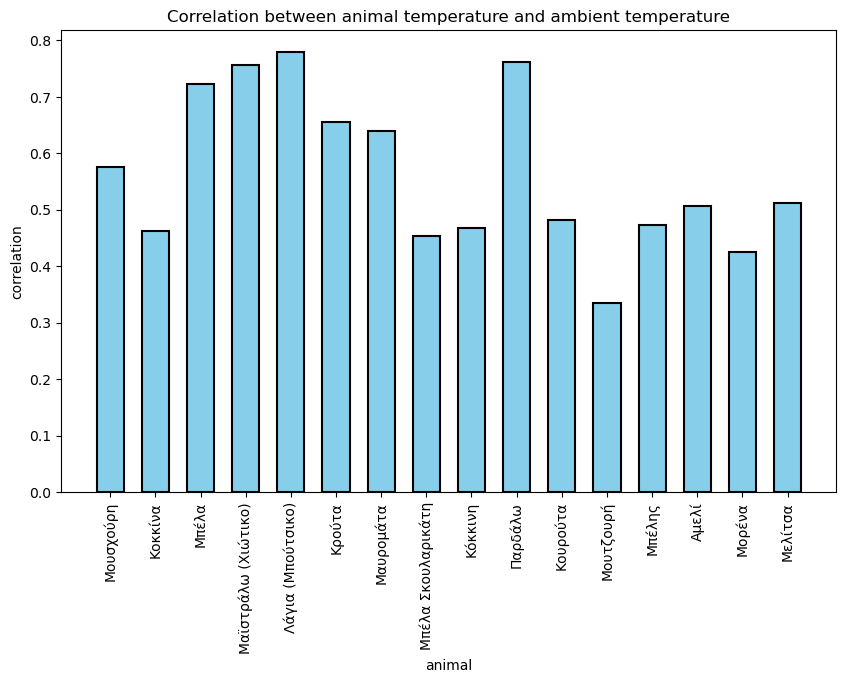

In [50]:
animal_names = [animal_names[i] for i in range(num_animals) if not np.isnan(corrs[i])]
corrs = [corrs[i] for i in range(len(corrs)) if not np.isnan(corrs[i])]

# Initialize figure
plt.figure(figsize=(10, 6))

# Create barplot
plt.bar(animal_names, corrs, width=0.6, color='skyblue', edgecolor='black', linewidth=1.5)

# Set title
plt.title("Correlation between animal temperature and ambient temperature")

# Set ticks and labels
plt.xticks(rotation=90)
plt.ylabel('correlation')
plt.xlabel('animal')

# Part 3: Compute the average distance between all pairs of animals

In [57]:
def haversine(coord1, coord2):
    """
    coord1, coord2: str (lon, lat)
    Returns the distance (in km) between coord1 and coord2
    """
    lon1, lat1 = ast.literal_eval(coord1)
    lon2, lat2 = ast.literal_eval(coord2)

    # Convert degrees to radians
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])

    # Haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    R = 6371000  # Earth radius in meters
    return R * c / 1000

num_animals = df_animals.shape[0]
device_ids = df_animals['id_api'].tolist()

# Initialize matrix to store average distances
A = np.zeros((num_animals, num_animals))

for i in range(num_animals):
    # Extract device data for first sheep
    df1 = df_device_data[df_device_data['id_api'] == device_ids[i]].copy()
    df1 = df1[['created', 'coordinates']]
    for j in range(i, num_animals):
        # Extract device data for second sheep
        df2 = df_device_data[df_device_data['id_api'] == device_ids[j]].copy()
        df2 = df2[['created', 'coordinates']]

        # Merge df1 and df2 based on time
        # Match each row from df1 with the nearest row in df2 based on 'created'
        df_merged = pd.merge_asof(
            df1, df2,
            on='created',
            direction='nearest',  # can also use 'forward' or 'backward'
            tolerance=pd.Timedelta('30min'),
            suffixes=('_df1', '_df2')
        )

        # Drop rows where no match was found
        df_merged = df_merged.dropna()
        #print(df_merged.head())
        # Compute distance (in km) between sheep in aligned rows
        # Add a new column to the dataframe that stores distance
        df_merged['dist'] = df_merged.apply(lambda row: haversine(row['coordinates_df1'], row['coordinates_df2']), axis=1)
        
        # Store the average distance in matrix A
        A[i,j] = df_merged['dist'].mean()
        A[j,i] = A[i,j]
        print(df_merged['dist'].mean())

0.0
0.04494072009375714
0.04193620375326505
129.49127363512244
129.51124851003092
129.5225395036012
15.338094999824797
77.55615612937584
15.451244992570375
15.429668030389157
15.32073745571112
15.411567290255215
27.33421342346949
27.35305922350216
27.35647230223058
27.356927641649047
0.0
0.0447163390555605
129.48791251926812
129.50695222274925
129.5185133646149
15.317066587964186
74.52808471969747
15.43692594150506
15.402041294946393
15.279730997440526
15.39186705620936
27.31608602252378
27.344079725846854
27.34602047862284
27.346446156406614
0.0
129.49724178126294
129.51772413464164
129.5285518814241
15.356016814089886
73.92543956832232
15.48603918231709
15.413296860180166
15.368187294211396
15.45522161578993
27.37943416490265
27.378216365474454
27.377067543635093
27.37790994663138
0.0
0.043126705524341336
0.045480235267828004
144.75779637377087
210.0301911540109
144.8794383804382
144.84504889452828
144.7280595589402
144.83865465730895
122.16566134581463
122.16028640966289
122.1606758

### Visualize distances

In [58]:
print(A

[[0.00000000e+00 4.49407201e-02 4.19362038e-02 1.29491274e+02
  1.29511249e+02 1.29522540e+02 1.53380950e+01 7.75561561e+01
  1.54512450e+01 1.54296680e+01 1.53207375e+01 1.54115673e+01
  2.73342134e+01 2.73530592e+01 2.73564723e+01 2.73569276e+01]
 [4.49407201e-02 0.00000000e+00 4.47163391e-02 1.29487913e+02
  1.29506952e+02 1.29518513e+02 1.53170666e+01 7.45280847e+01
  1.54369259e+01 1.54020413e+01 1.52797310e+01 1.53918671e+01
  2.73160860e+01 2.73440797e+01 2.73460205e+01 2.73464462e+01]
 [4.19362038e-02 4.47163391e-02 0.00000000e+00 1.29497242e+02
  1.29517724e+02 1.29528552e+02 1.53560168e+01 7.39254396e+01
  1.54860392e+01 1.54132969e+01 1.53681873e+01 1.54552216e+01
  2.73794342e+01 2.73782164e+01 2.73770675e+01 2.73779099e+01]
 [1.29491274e+02 1.29487913e+02 1.29497242e+02 0.00000000e+00
  4.31267055e-02 4.54802353e-02 1.44757796e+02 2.10030191e+02
  1.44879438e+02 1.44845049e+02 1.44728060e+02 1.44838655e+02
  1.22165661e+02 1.22160286e+02 1.22160676e+02 1.22160116e+02]
 [1.

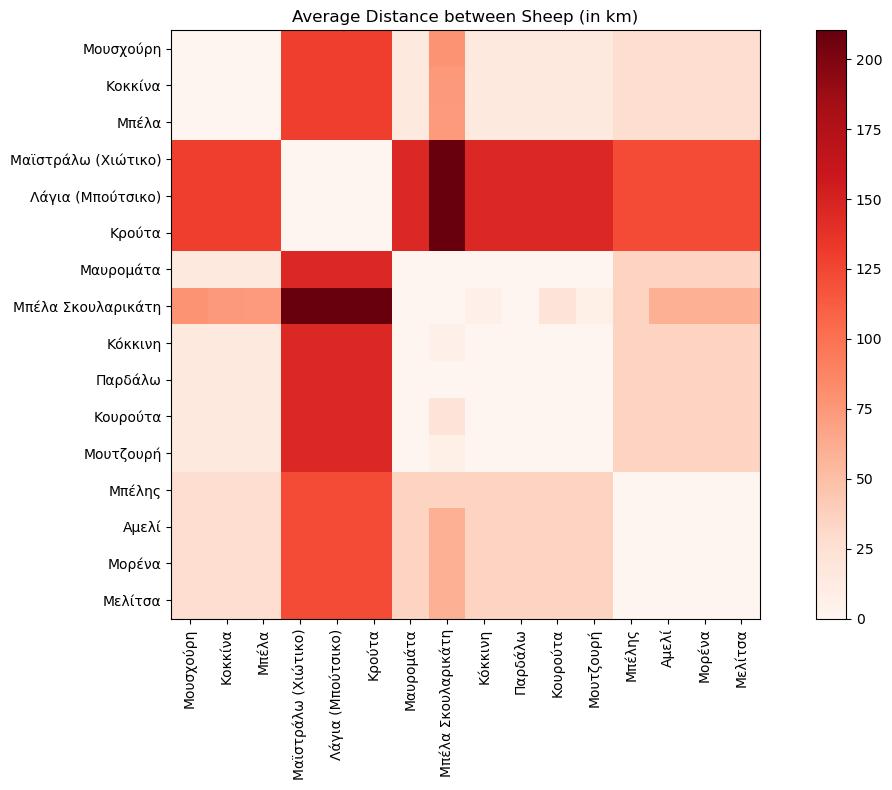

In [59]:
animal_names = df_animals['name'].tolist()

# Initialize figure
plt.figure(figsize=(12, 8))

# Show matrix as an image
im = plt.imshow(A, cmap='Reds')

# Add colorbar
plt.colorbar(im)

# Set ticks and labels
plt.xticks(ticks=np.arange(len(animal_names)), labels=animal_names, rotation=90)
plt.yticks(ticks=np.arange(len(animal_names)), labels=animal_names, rotation=0)

# Set title
plt.title("Average Distance between Sheep (in km)")
plt.tight_layout()

### Visualize predictions vs. ground-truth values

In [ ]:
# Initialize figure
plt.figure(figsize=(10, 6))

# Create scatter plot
plt.scatter(y_test, y_pred, alpha=0.6)

# Plot diagonal line
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--') 

# Set labels
plt.xlabel('Ground Truth')
plt.ylabel('Predicted')

# Set title
plt.title('Predicted temperatures vs. ground-truth temperatures')
plt.tight_layout()